# required packages

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [51]:
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error

# Exercise 4.4.1) Simulate an MA(2) process and make forecasts

## 1.  For this exercise, generate 1,000 samples.

In [3]:
np.random.seed(42)
ma2 = np.array([1, 0.9, 0.3])
ar0 = np.array([1, 0, 0])

ma2_process = ArmaProcess(ar0, ma2).generate_sample(nsample=1000)

## 2. Plot your simulated moving average.

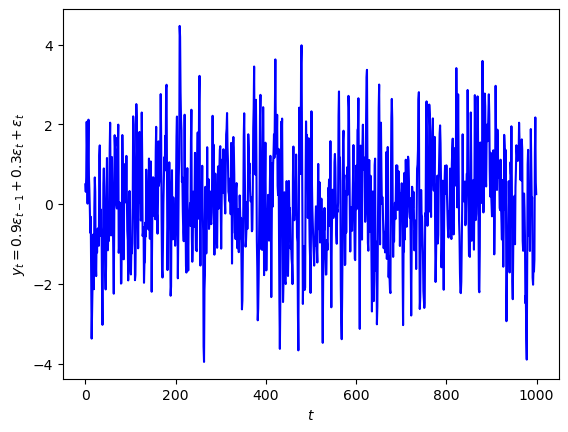

In [4]:
fig, ax = plt.subplots()
ax.plot(ma2_process, 'b-')
ax.set_xlabel('$t$')
ax.set_ylabel('$y_t = 0.9 \epsilon_{t-1} + 0.3 \epsilon_t + \epsilon_t$')
plt.show()

## 3. Run the ADF test, and check if the process is stationary.

In [5]:
adfuller(ma2_process)

(-14.005444309194495,
 3.7956016167135026e-26,
 3,
 996,
 {'1%': -3.4369325637409154,
  '5%': -2.8644462162311934,
  '10%': -2.568317409920808},
 2739.7287503892885)

O processo é estacionário, pois o valor-p é zero.

## 4. Plot the ACF, and see if there are significant coefficients after lag 2.

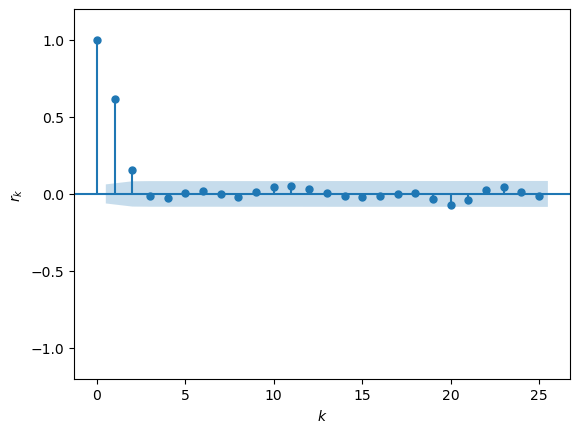

In [6]:
fig, ax = plt.subplots()
plot_acf(ma2_process, lags=25, ax=ax)
ax.set_xlabel('$k$')
ax.set_ylabel('$r_k$')
ax.set_title('')
ax.set_ylim([-1.2, 1.2])
plt.show()

## 5. Separate your simulated series into train and test sets. Take the first 800 time- steps for the train set, and assign the rest to the test set.

In [7]:
train = ma2_process[:800]
test = ma2_process[800:]

## 6. Make forecasts over the test set. Use the mean, last value, and an MA(2) model. Make sure you repeatedly forecast 2 timesteps at a time using the recursive forecast function we defined.

In [101]:
def rolling_forecast(df: pd.DataFrame, column: str, train_len: int, horizon: int, window: int, method: str) -> list:
    """
    Compute rolling forecast for a Time Series using last value, mean or MA(2) model.

    It takes a DataFrame object with train and test data points.

    Args:
    -----
        df (pd.DataFrame): 
            DataFrame with all data points
        column (str):
            column to be forecast
        train_len (int): 
            number of data points used to fit the model 
        horizon (int):
            length of test set
        window (int):
            number of timesteps predicted at time
        method (str):
            specifies what model to use. It must be "last", "mean", "MA"

    Returns:
    --------
        list: predicted values
    """

    total_len = train_len + horizon

    if method == 'mean':
        pred_mean = []
    
        for i in range(train_len, total_len, window):
            mean = np.mean(list(df.loc[:, column].iloc[:i]))
            pred_mean.extend(mean for _ in range(window))
            
        return pred_mean[:horizon]

    if method == 'last':
        pred_last_value = []
        
        for i in range(train_len, total_len, window):
            last_value = df.loc[:, column].iloc[:i].iloc[-1]
            pred_last_value.extend(last_value for _ in range(window))
            
        return pred_last_value[:horizon]

    if method == 'MA':
        pred_ma = []
        for i in range(train_len, total_len, window):
            model = SARIMAX(
                list(df.loc[:, column].iloc[:i]), 
                order=(0,0,2)
            )
            res = model.fit(disp=False)
            predictions = res.get_prediction(0, i + window - 1)
            oos_pred = predictions.predicted_mean[-window:]
            pred_ma.extend(oos_pred)
            
        return pred_ma[:horizon]

In [45]:
df_ma2 = pd.DataFrame({'ma2': ma2_process})
df_ma2.head()

,ma2
0,0.496714
1,0.308778
2,0.672265
3,2.064470
4,1.330880


In [46]:
?rolling_forecast

Signature:
rolling_forecast(
    df: pandas.core.frame.DataFrame,
    column: str,
    train_len: int,
    horizon: int,
    window: int,
    method: str,
) -> list
Docstring:
Compute rolling forecast for a Time Series using last value, mean or MA(2) model.

It takes a DataFrame object with train and test data points.

Args:
-----
    df (pd.DataFrame): 
        DataFrame with all data points
    column (str):
        column to be forecast
    train_len (int): 
        number of data points used to fit the model 
    horizon (int):
        length of test set
    window (int):
        number of timesteps predicted at time
    method (str):
        specifies what model to use. It must be "last", "mean", "MA"

Returns:
--------
    list: predicted values
File:      /tmp/ipykernel_6950/858412268.py
Type:      function

In [47]:
df_pred = pd.DataFrame({
    'actual': df_ma2.loc[800:, 'ma2'],
    'last':  rolling_forecast(df_ma2, 'ma2', 800, 200, 2, 'last'),
    'mean': rolling_forecast(df_ma2, 'ma2', 800, 200, 2, 'mean'),
    'MA': rolling_forecast(df_ma2, 'ma2', 800, 200, 2, 'MA')
}, index = df_ma2.index[800:])

In [48]:
df_pred.head()

,actual,last,mean,MA
800,0.973560,0.259693,-0.017430,0.065366
801,0.337338,0.259693,-0.017430,0.017984
802,-0.086834,0.337338,-0.015752,-0.180397
803,-0.530580,0.337338,-0.015752,-0.116820
804,-0.821708,-0.530580,-0.016481,-0.405768


## 7. Plot your forecasts.

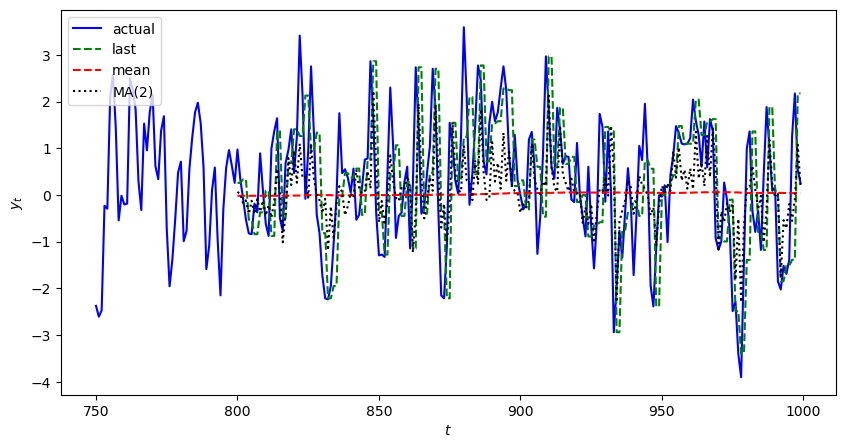

In [53]:
fig, ax = plt.subplots(figsize=(10,5))
ax.plot(df_ma2[750:], 'b-', label='actual')
ax.plot(df_pred['last'], 'g--', label='last')
ax.plot(df_pred['mean'], 'r--', label='mean')
ax.plot(df_pred['MA'], 'k:', label='MA(2)')
ax.set_xlabel('$t$')
ax.set_ylabel('$y_t$')
ax.legend(loc='upper left')
plt.show()

In [54]:
mse = pd.Series({
    'last': mean_squared_error(df_pred['actual'], df_pred['last']),
    'mean': mean_squared_error(df_pred['actual'], df_pred['mean']),
    'MA(2)': mean_squared_error(df_pred['actual'], df_pred['MA']),
})

In [55]:
mse

last     1.988202
mean     1.863501
MA(2)    1.232354
dtype: float64

## 8. Plot your MSEs in a bar plot.

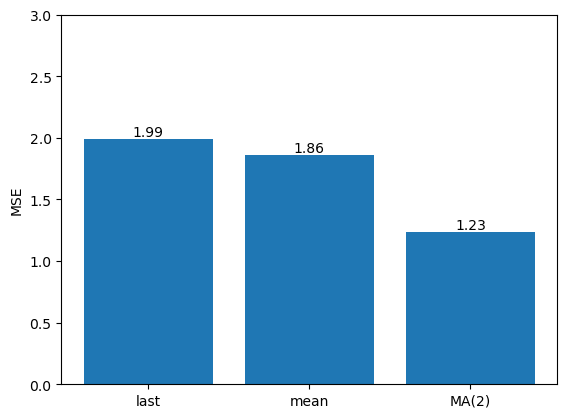

In [60]:
fig, ax = plt.subplots()
bars = ax.bar(mse.index, mse.values)
ax.set_ylabel('MSE')
ax.bar_label(bars, fmt="%.2f")
ax.set_ylim([0, 3])
plt.show()

# Exercise 4.4.2) Simulate an MA(q) process and make forecasts

In [76]:
np.random.seed(42)

ma3 = np.array([1, 0.9, 0.3, 0.2])
ar3 = np.array([1])

ma3 = ArmaProcess(ar3, ma3).generate_sample(nsample=10000)

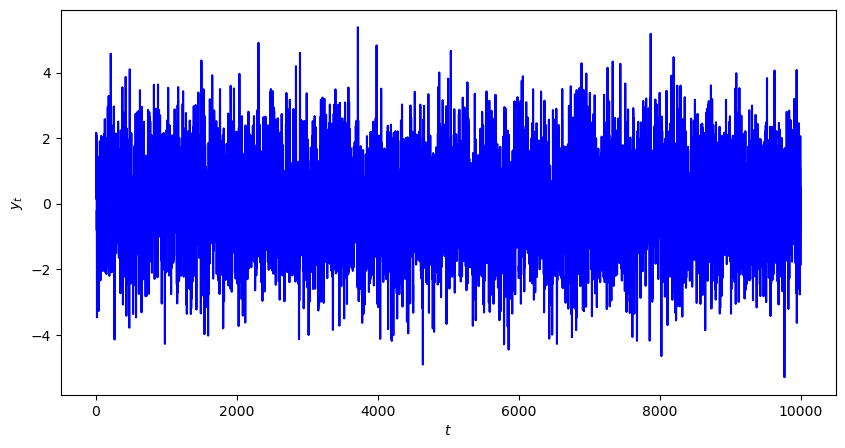

In [77]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(ma3, 'b-')
ax.set_xlabel('$t$')
ax.set_ylabel('$y_t$')
plt.show()

In [78]:
adfuller(ma3)

(-22.871933261080763,
 0.0,
 17,
 9982,
 {'1%': -3.4310052777423485,
  '5%': -2.8618295937252394,
  '10%': -2.566924145602738},
 28353.057938106474)

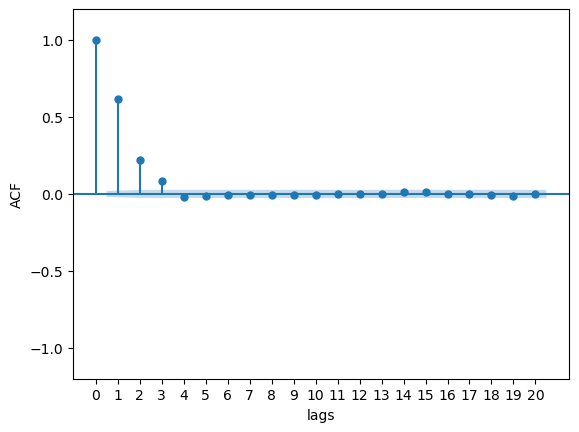

In [79]:
fig, ax = plt.subplots()
plot_acf(ma3, lags=20, ax=ax)
ax.set_ylim([-1.2, 1.2])
ax.set_xticks(np.arange(0, 21, 1))
ax.set_xlabel('lags')
ax.set_ylabel('ACF')
ax.set_title('')
plt.show()

In [81]:
df_ma3 = pd.DataFrame({'ma3': ma3})
train = ma3[:-200]
test = ma3[-200:]

In [82]:
?rolling_forecast

Signature:
rolling_forecast(
    df: pandas.core.frame.DataFrame,
    column: str,
    train_len: int,
    horizon: int,
    window: int,
    method: str,
) -> list
Docstring:
Compute rolling forecast for a Time Series using last value, mean or MA(2) model.

It takes a DataFrame object with train and test data points.

Args:
-----
    df (pd.DataFrame): 
        DataFrame with all data points
    column (str):
        column to be forecast
    train_len (int): 
        number of data points used to fit the model 
    horizon (int):
        length of test set
    window (int):
        number of timesteps predicted at time
    method (str):
        specifies what model to use. It must be "last", "mean", "MA"

Returns:
--------
    list: predicted values
File:      /tmp/ipykernel_6950/858412268.py
Type:      function

## Prediction

In [104]:
def rolling_forecast_ma3(df: pd.DataFrame, column: str, train_len: int, horizon: int, window: int, method: str) -> list:
    """
    Compute rolling forecast for a Time Series using last value, mean or MA(2) model.

    It takes a DataFrame object with train and test data points.

    Args:
    -----
        df (pd.DataFrame): 
            DataFrame with all data points
        column (str):
            column to be forecast
        train_len (int): 
            number of data points used to fit the model 
        horizon (int):
            length of test set
        window (int):
            number of timesteps predicted at time
        method (str):
            specifies what model to use. It must be "last", "mean", "MA"

    Returns:
    --------
        list: predicted values
    """

    total_len = train_len + horizon

    if method == 'mean':
        pred_mean = []
    
        for i in range(train_len, total_len, window):
            mean = np.mean(list(df.loc[:, column].iloc[:i]))
            pred_mean.extend(mean for _ in range(window))
            
        return pred_mean[:horizon]

    if method == 'last':
        pred_last_value = []
        
        for i in range(train_len, total_len, window):
            last_value = df.loc[:, column].iloc[:i].iloc[-1]
            pred_last_value.extend(last_value for _ in range(window))
            
        return pred_last_value[:horizon]

    if method == 'MA':
        pred_ma = []
        for i in range(train_len, total_len, window):
            model = SARIMAX(
                list(df.loc[:, column].iloc[:i]), 
                order=(0,0,3)
            )
            res = model.fit(disp=False)
            predictions = res.get_prediction(0, i + window - 1)
            oos_pred = predictions.predicted_mean[-window:]
            pred_ma.extend(oos_pred)
            
        return pred_ma[:horizon]

In [120]:
TRAIN_LEN = len(train)
HORIZON = len(test)
WINDOW = 3


df_pred_ma3 = pd.DataFrame({
    'actual': test,
    'mean': rolling_forecast_ma3(df_ma3, 'ma3', TRAIN_LEN, HORIZON, WINDOW, 'mean'),
    'last': rolling_forecast_ma3(df_ma3, 'ma3', TRAIN_LEN, HORIZON, WINDOW, 'last'),
    'ma': rolling_forecast_ma3(df_ma3, 'ma3', TRAIN_LEN, HORIZON, WINDOW, 'MA'),
}, index = df_ma3[-HORIZON:].index)

In [122]:
mse = pd.Series({
    'last': mean_squared_error(df_pred_ma3['actual'], df_pred_ma3['last']),
    'mean': mean_squared_error(df_pred_ma3['actual'], df_pred_ma3['mean']),
    'ma': mean_squared_error(df_pred_ma3['actual'], df_pred_ma3['ma'])
})

In [123]:
mse

last    3.186553
mean    1.924814
ma      1.506528
dtype: float64

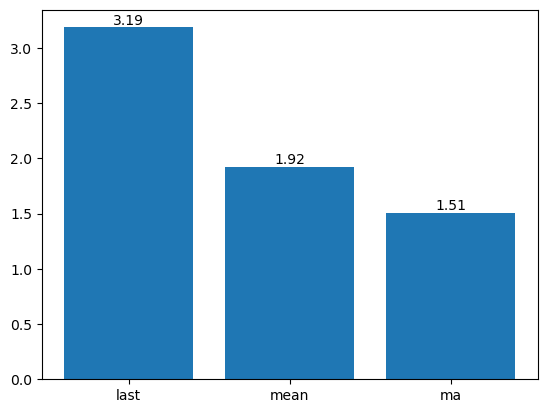

In [124]:
fig, ax = plt.subplots()
bars = ax.bar(mse.index, mse.values)
ax.bar_label(bars, fmt='%.2f')
plt.show()

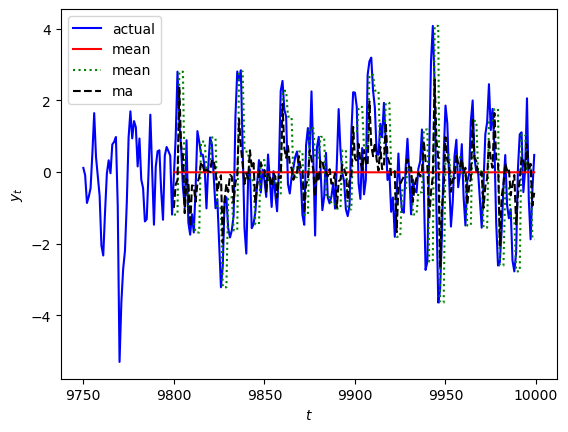

In [126]:
fig, ax = plt.subplots()
ax.plot(df_ma3[-250:], 'b-', label='actual')
ax.plot(df_pred_ma3['mean'], 'r-', label='mean')
ax.plot(df_pred_ma3['last'], 'g:', label='mean')
ax.plot(df_pred_ma3['ma'], 'k--', label='ma')
ax.set_xlabel('$t$')
ax.set_ylabel('$y_t$')
ax.legend(loc='upper left')
plt.show()